1. Loading Image...
2. Parsing SAM JSON for Ground Truth...
   -> JSON parsed successfully. Extracted GT mask for pixel [200, 700].
3. Defining Overlay Helper Function...
4. Running FastSAM-x...

image 1/1 d:\sems\AIP\Proj\code\sa_2.jpg: 704x1024 1 object, 127.2ms
Speed: 4.8ms preprocess, 127.2ms inference, 22.6ms postprocess per image at shape (1, 3, 704, 1024)
5. Processing FastSAM Mask & Applying Optimized GrabCut...
   -> GrabCut completed in 3.39 seconds on cropped region.
6. Generating Overlays...
7. Plotting Results...
   -> Plot saved successfully as example_plot.png


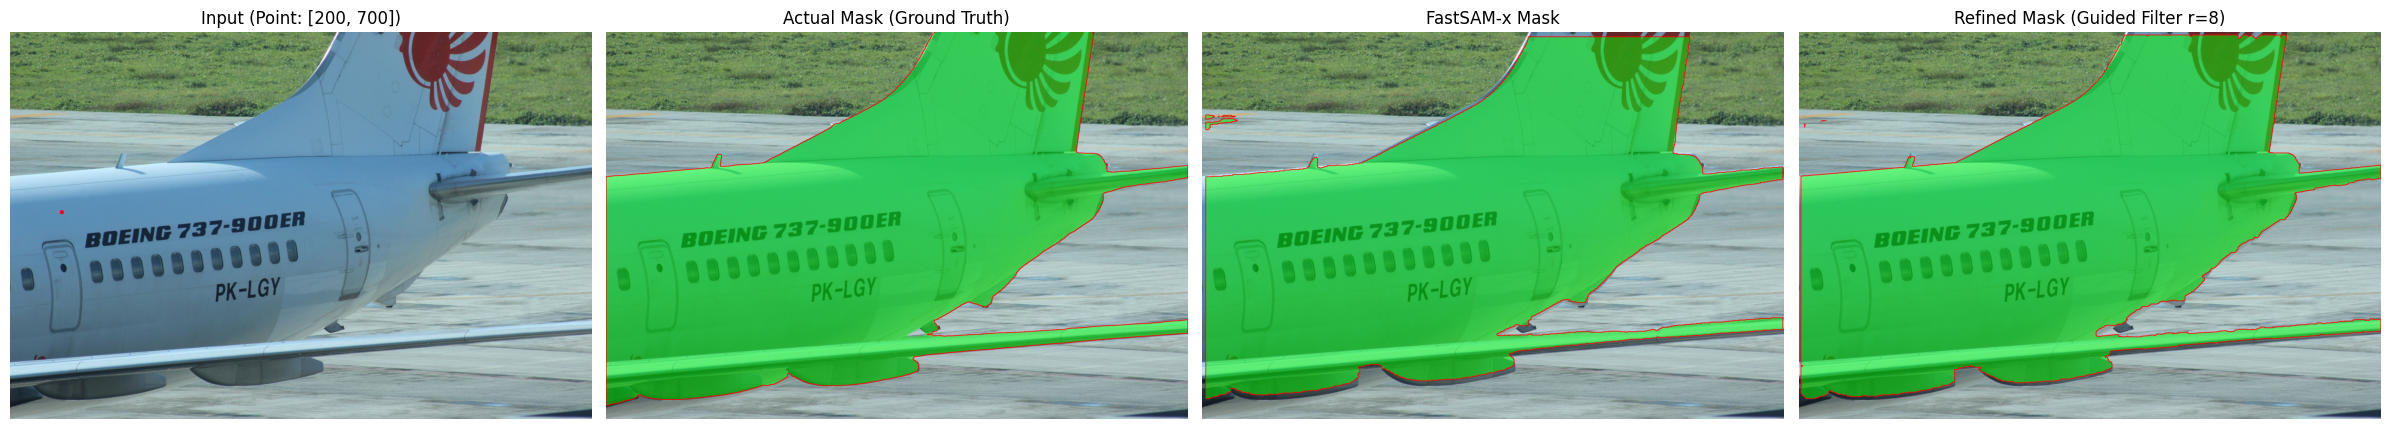

Done!


In [12]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import FastSAM
import time

dummy_point = [200, 700]  

print("1. Loading Image...")
image_path = 'sa_2.jpg' # Ensure this is your correct image name
img = cv2.imread(image_path)
if img is None:
    raise ValueError(f"Could not load {image_path}. Check the file name/path!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
original_shape = img.shape[:2]

print("2. Parsing SAM JSON for Ground Truth...")
json_path = 'sa_2.json' 
actual_mask = np.zeros(original_shape, dtype=np.uint8)

try:
    with open(json_path, 'r') as f:
        data = json.load(f)
        
        px, py = dummy_point # x, y
        min_area = float('inf')
        
        # Loop through all detected objects in the JSON
        for ann in data.get('annotations', []):
            seg = ann['segmentation']
            
            # Decode SAM's RLE format
            if isinstance(seg, dict):
                h, w = seg['size']
                counts = seg['counts']
                
                if isinstance(counts, list):
                    mask_1d = np.zeros(h * w, dtype=np.uint8)
                    pos = 0
                    for j, count in enumerate(counts):
                        if j % 2 == 1: 
                            mask_1d[pos : pos + count] = 1
                        pos += count
                    seg_mask = mask_1d.reshape((w, h)).T
                else:
                    from pycocotools import mask as maskUtils
                    seg_mask = maskUtils.decode(seg)
            else:
                seg_mask = np.array(seg, dtype=np.uint8)
            
            # CHECK: Is our pixel actually inside this mask?
            # Note: numpy arrays are indexed [y, x]
            if py < seg_mask.shape[0] and px < seg_mask.shape[1] and seg_mask[py, px] > 0:
                # If there are multiple overlapping masks, pick the tightest one (smallest area)
                area = ann.get('area', np.sum(seg_mask))
                if area < min_area:
                    min_area = area
                    actual_mask = seg_mask.copy()
            
    if actual_mask.max() == 0:
        print(f"   -> ⚠️ Warning: No mask found in JSON that covers pixel {dummy_point}.")
    else:
        print(f"   -> JSON parsed successfully. Extracted GT mask for pixel {dummy_point}.")

except Exception as e:
    print(f"   -> ❌ FAILED at JSON parsing: {e}")
print("3. Defining Overlay Helper Function...")
def create_overlay_with_boundary(img_base, mask, mask_color=(0, 255, 0), boundary_color=(255, 0, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, boundary_color, 2)
    return overlay


print("4. Running FastSAM-x...")
# ---------------------------------------------------------
dummy_point = [200, 700]  # <--- CHANGE THIS PIXEL
# ---------------------------------------------------------
model = FastSAM("FastSAM-x.pt")
results = model(image_path, points=[dummy_point], labels=[1])

if results[0].masks is not None:
    print("5. Processing FastSAM Mask & Applying Optimized GrabCut...")
    
    fastsam_mask_raw = results[0].masks.data.cpu().numpy()[0]
    
    # Resize with INTER_NEAREST to keep it strictly binary (0 or 1)
    fastsam_mask = cv2.resize(fastsam_mask_raw, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)
    fastsam_mask = (fastsam_mask > 0.5).astype(np.uint8)
    
    # --- OPTIMIZATION: Crop to Bounding Box ---
    # Find the coordinates where the FastSAM mask is active
    y_indices, x_indices = np.where(fastsam_mask == 1)
    
    if len(y_indices) > 0:
        # Get bounding box with a margin (e.g., 30 pixels) for background context
        margin = 30
        y_min = max(0, y_indices.min() - margin)
        y_max = min(original_shape[0], y_indices.max() + margin)
        x_min = max(0, x_indices.min() - margin)
        x_max = min(original_shape[1], x_indices.max() + margin)
        
        # Slice the image and mask arrays
        img_crop = img_rgb[y_min:y_max, x_min:x_max]
        mask_crop = fastsam_mask[y_min:y_max, x_min:x_max]
        
        # Setup GrabCut for the tiny cropped area
        gc_mask_crop = np.full(mask_crop.shape, 2, dtype=np.uint8) 
        
        # Slightly smaller kernel since we are potentially working on a smaller crop
        kernel = np.ones((15, 15), np.uint8) 
        sure_fg = cv2.erode(mask_crop, kernel, iterations=1)
        sure_bg = cv2.dilate(mask_crop, kernel, iterations=1)
        sure_bg = 1 - sure_bg 
        
        gc_mask_crop[mask_crop == 1] = 3 
        gc_mask_crop[sure_fg == 1] = 1      
        gc_mask_crop[sure_bg == 1] = 0      

        bgdModel = np.zeros((1, 65), np.float64)
        fgdModel = np.zeros((1, 65), np.float64)
        
        # Run GrabCut on the CROP with 3 iterations
        start_time = time.time()
        cv2.grabCut(img_crop, gc_mask_crop, None, bgdModel, fgdModel, iterCount=3, mode=cv2.GC_INIT_WITH_MASK)
        end_time = time.time()
        print(f"   -> GrabCut completed in {end_time - start_time:.2f} seconds on cropped region.")

        # Extract the refined crop mask
        refined_mask_crop = np.where((gc_mask_crop == 1) | (gc_mask_crop == 3), 1, 0).astype(np.uint8)
        
        # Create an empty full-size mask and paste the refined crop back into it
        refined_mask = np.zeros_like(fastsam_mask)
        refined_mask[y_min:y_max, x_min:x_max] = refined_mask_crop
    else:
        # Fallback just in case the mask is totally empty
        refined_mask = fastsam_mask.copy()
    
    print("6. Generating Overlays...")
    overlay_actual = create_overlay_with_boundary(img_rgb, actual_mask)
    overlay_fastsam = create_overlay_with_boundary(img_rgb, fastsam_mask)
    overlay_refined = create_overlay_with_boundary(img_rgb, refined_mask)

    print("7. Plotting Results...")
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    img_with_point = img_rgb.copy()
    cv2.circle(img_with_point, (dummy_point[0], dummy_point[1]), radius=8, color=(255, 0, 0), thickness=-1)
    
    axes[0].imshow(img_with_point)
    axes[0].set_title(f"Input (Point: {dummy_point})")
    axes[0].axis('off')
    
    axes[1].imshow(overlay_actual)
    axes[1].set_title("Actual Mask (Ground Truth)")
    axes[1].axis('off')
    
    axes[2].imshow(overlay_fastsam)
    axes[2].set_title("FastSAM-x Mask")
    axes[2].axis('off')
    
    axes[3].imshow(overlay_refined)
    axes[3].set_title(f"Refined Mask (Guided Filter r={r})")
    axes[3].axis('off')
    
    plt.tight_layout()
    save_path = 'example_plot.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"   -> Plot saved successfully as {save_path}")
    
    plt.show()
    print("Done!")
else:
    print("❌ FastSAM could not find an object at the provided pixel.")

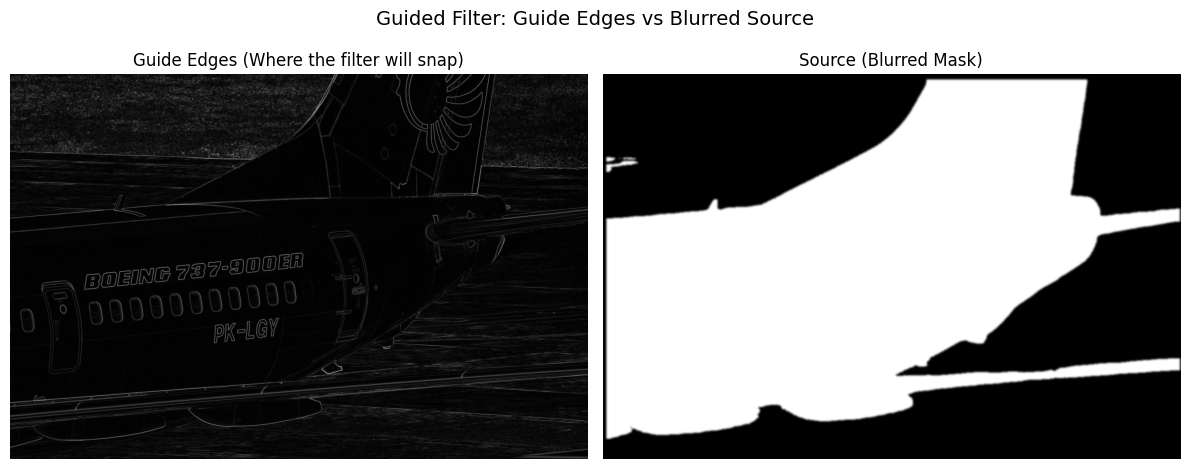

In [4]:
# --- DEBUG PLOT: See the "Edges" the Guided Filter will use ---
# Convert guide to grayscale to compute edges
gray_guide = cv2.cvtColor(guide, cv2.COLOR_RGB2GRAY)

# Calculate gradients (edges) using Sobel
sobelx = cv2.Sobel(gray_guide, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_guide, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = cv2.magnitude(sobelx, sobely)

# Normalize back to 0-255 for plotting
edges_normalized = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(edges_normalized, cmap='gray')
axes[0].set_title("Guide Edges (Where the filter will snap)")
axes[0].axis('off')

axes[1].imshow(src, cmap='gray')
axes[1].set_title("Source (Blurred Mask)")
axes[1].axis('off')

plt.suptitle("Guided Filter: Guide Edges vs Blurred Source", fontsize=14)
plt.tight_layout()
plt.show()
# --------------------------------------------------------------